In [1]:

from google.colab import files
print("Please upload your file:")
uploaded = files.upload()
!ls -la

Please upload your file:


Saving Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv.zip to Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv.zip
total 18232
drwxr-xr-x 1 root root     4096 Mar 20 01:52 .
drwxr-xr-x 1 root root     4096 Mar 20 01:43 ..
drwxr-xr-x 4 root root     4096 Feb  6 14:31 .config
-rw-r--r-- 1 root root 18649646 Mar 20 01:52 Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv.zip
drwxr-xr-x 1 root root     4096 Feb  6 14:31 sample_data


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')


# 1. LOAD THE DATASET
print("\n[1] Loading CIC-IDS-2017 dataset...")

df = pd.read_csv('Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv.zip',
                 encoding='utf-8',
                 skipinitialspace=True,
                 low_memory=False)

print(f"Loaded {len(df):,} network flows")
print(f"Features: {df.shape[1]}")

# Display basic info
print("\nFirst few rows:")
print(df.head())

# Check column names (they often have spaces)
print("\nColumns:")
print(df.columns.tolist())


label_col = [col for col in df.columns if 'label' in col.lower()][0]
print(f"\nLabel column: '{label_col}'")
print("\nClass distribution:")
print(df[label_col].value_counts())


[1] Loading CIC-IDS-2017 dataset...
Loaded 225,745 network flows
Features: 79

First few rows:
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             54865              3                  2                       0   
1             55054            109                  1                       1   
2             55055             52                  1                       1   
3             46236             34                  1                       1   
4             54863              3                  2                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           12                            0   
1                            6                            6   
2                            6                            6   
3                            6                            6   
4                           12                            0   

   Fwd Packet Length Max  Fwd Packet L


[2] Exploratory Analysis: Normal vs Attack Behavior
Analyzing 78 numerical features


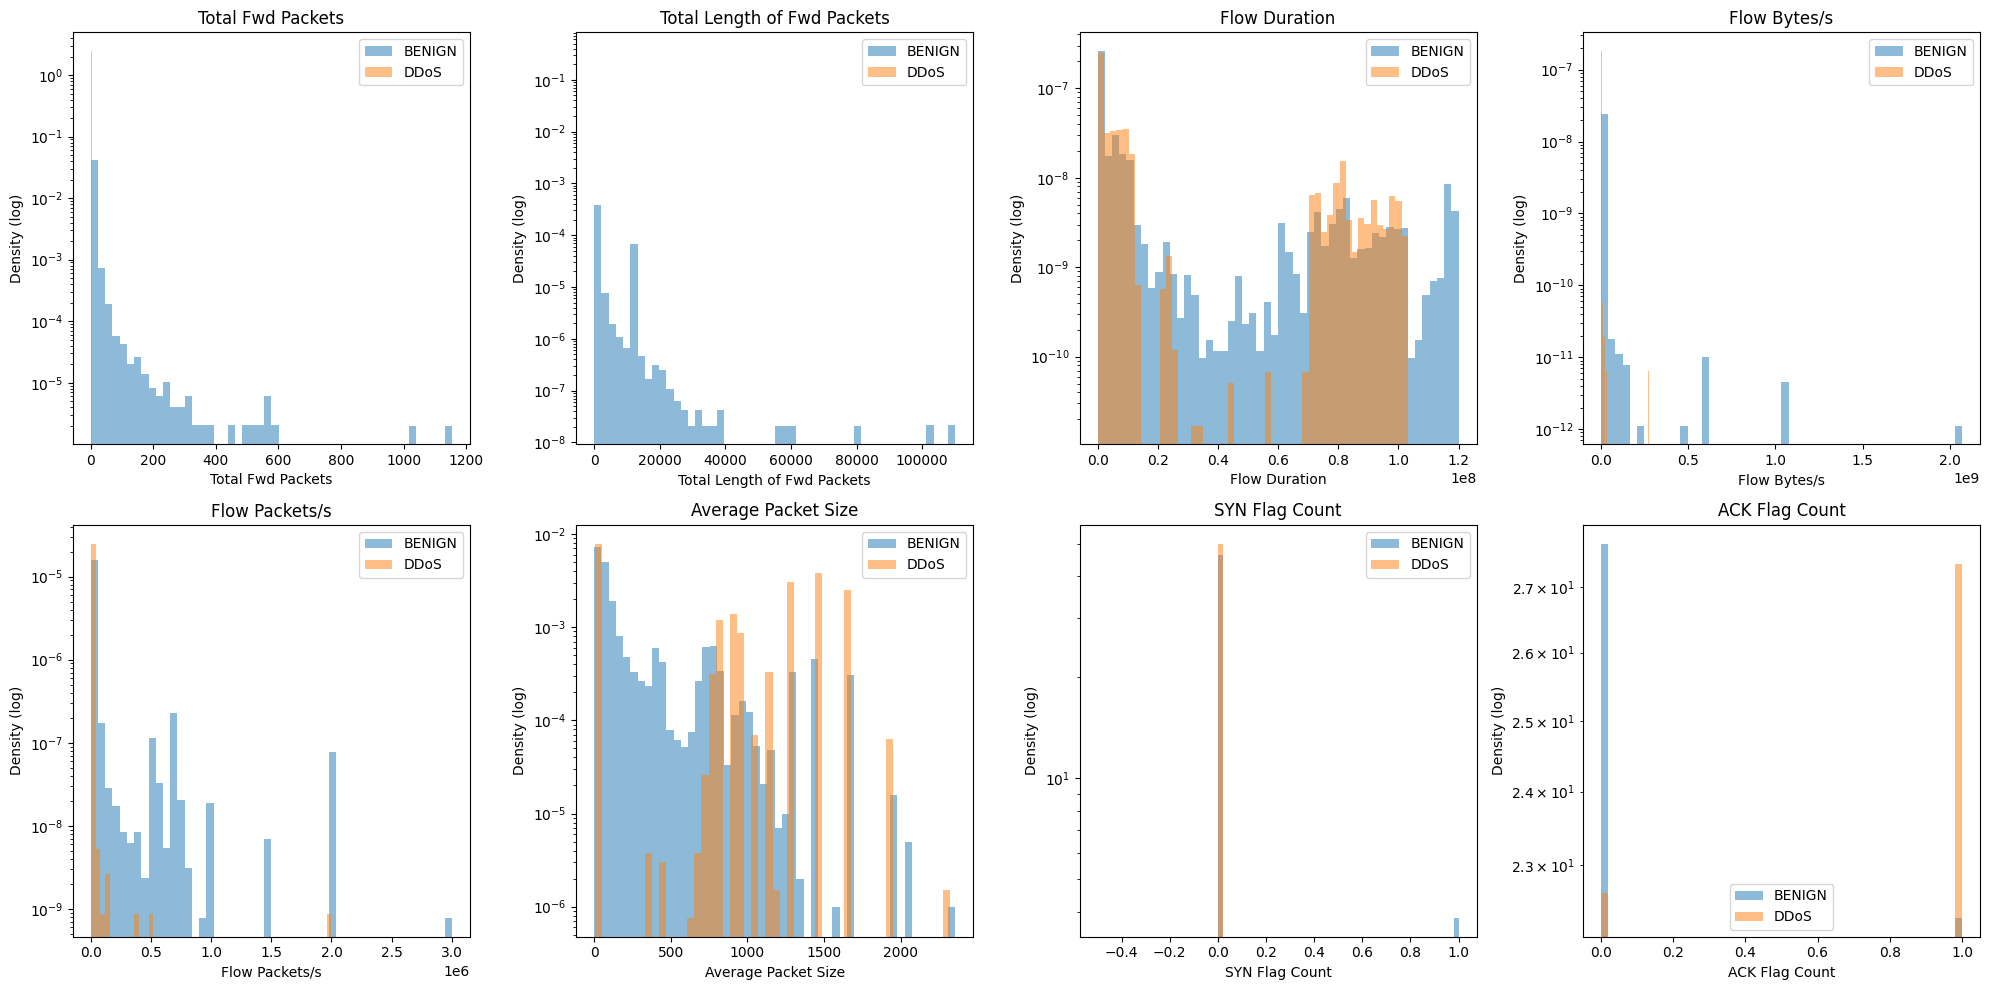

                                  BENIGN         DDoS  Ratio (DDoS/BENIGN)
Total Fwd Packets                   5.40         4.47                 0.83
Total Length of Fwd Packets      2128.51        31.91                 0.01
Flow Duration                15306262.91  16955591.77                 1.11
Flow Bytes/s                  1272497.80     61117.88                 0.05
Flow Packets/s                  32678.94       172.79                 0.01
Average Packet Size               249.59       822.61                 3.30
SYN Flag Count                      0.08         0.00                 0.00
ACK Flag Count                      0.45         0.55                 1.22


In [4]:
print("\n[2] Exploratory Analysis: Normal vs Attack Behavior")

# Select numerical columns (excluding Label)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Analyzing {len(numerical_cols)} numerical features")

# Take a sample for visualization
sample_size = min(50000, len(df))
df_sample = df.sample(n=sample_size, random_state=42)

# Replace inf values with NaN then drop or fill
df_sample = df_sample.replace([np.inf, -np.inf], np.nan)

# Compare key features between normal and attack traffic
key_features = ['Total Fwd Packets', 'Total Length of Fwd Packets',
                'Flow Duration', 'Flow Bytes/s', 'Flow Packets/s',
                'Average Packet Size', 'SYN Flag Count', 'ACK Flag Count']

# Ensure features exist
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, feature in enumerate(key_features[:8]):
    ax = axes[idx]

    # Get data for normal and attack, dropping NaN
    normal_data = df_sample[df_sample['Label'] == 'BENIGN'][feature].dropna()
    attack_data = df_sample[df_sample['Label'] == 'DDoS'][feature].dropna()

    # Plot distributions if we have finite data
    if len(normal_data) > 0 and len(attack_data) > 0:
        # Check if data is finite
        if np.isfinite(normal_data).all() and np.isfinite(attack_data).all():
            ax.hist(normal_data, bins=50, alpha=0.5, label='BENIGN', density=True, log=True)
            ax.hist(attack_data, bins=50, alpha=0.5, label='DDoS', density=True, log=True)
    ax.set_title(f'{feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Density (log)')
    ax.legend()

plt.tight_layout()
plt.savefig('feature_comparison.png', dpi=150)
plt.show()

# Statistical comparison
df['is_attack'] = (df['Label'] == 'DDoS').astype(int)

# Replace inf in the whole dataframe for comparison
df_clean = df.replace([np.inf, -np.inf], np.nan)
comparison = df_clean.groupby('is_attack')[key_features].mean().T
comparison.columns = ['BENIGN', 'DDoS']
comparison['Ratio (DDoS/BENIGN)'] = comparison['DDoS'] / comparison['BENIGN']
print(comparison.round(2))

In [5]:
print("\n[3] Feature Engineering for Behavioral Profiles")

df_behavior = df.copy()
df_behavior['is_attack'] = (df_behavior['Label'] == 'DDoS').astype(int)

# Replace inf values first
df_behavior = df_behavior.replace([np.inf, -np.inf], np.nan)

# 1. Packet rate features - add small epsilon to avoid division by zero
df_behavior['packets_per_second'] = df_behavior['Total Fwd Packets'] / (df_behavior['Flow Duration'] + 1e-10)
df_behavior['bytes_per_packet'] = df_behavior['Total Length of Fwd Packets'] / (df_behavior['Total Fwd Packets'] + 1e-10)

# 2. Flag ratios
df_behavior['syn_ack_ratio'] = df_behavior['SYN Flag Count'] / (df_behavior['ACK Flag Count'] + 1e-10)
df_behavior['flag_diversity'] = (df_behavior['SYN Flag Count'] > 0).astype(int) + \
                                 (df_behavior['ACK Flag Count'] > 0).astype(int) + \
                                 (df_behavior['FIN Flag Count'] > 0).astype(int) + \
                                 (df_behavior['RST Flag Count'] > 0).astype(int) + \
                                 (df_behavior['PSH Flag Count'] > 0).astype(int) + \
                                 (df_behavior['URG Flag Count'] > 0).astype(int)

# 3. Flow characteristics
df_behavior['fwd_bwd_ratio'] = df_behavior['Total Fwd Packets'] / (df_behavior['Total Backward Packets'] + 1e-10)
df_behavior['packet_size_variation'] = df_behavior['Packet Length Std'] / (df_behavior['Packet Length Mean'] + 1e-10)

# 4. IAT patterns
if 'Flow IAT Mean' in df_behavior.columns and 'Flow IAT Std' in df_behavior.columns:
    df_behavior['iat_cv'] = df_behavior['Flow IAT Std'] / (df_behavior['Flow IAT Mean'] + 1e-10)

# Fill any remaining NaN with 0
df_behavior = df_behavior.fillna(0)

print("Created new behavioral features:")
new_features = [col for col in df_behavior.columns if col not in df.columns and col != 'is_attack']
print(new_features)


[3] Feature Engineering for Behavioral Profiles
Created new behavioral features:
['packets_per_second', 'bytes_per_packet', 'syn_ack_ratio', 'flag_diversity', 'fwd_bwd_ratio', 'packet_size_variation', 'iat_cv']


In [6]:
# Aggregate by destination port
port_profiles = []

for port in df_behavior['Destination Port'].unique():
    port_data = df_behavior[df_behavior['Destination Port'] == port]

    if len(port_data) < 10:
        continue

    total_flows = len(port_data)
    attack_flows = port_data['is_attack'].sum()
    attack_rate = attack_flows / total_flows if total_flows > 0 else 0

    port_profiles.append({
        'port': port,
        'total_flows': total_flows,
        'attack_flows': attack_flows,
        'attack_rate': attack_rate,
        'avg_flow_duration': port_data['Flow Duration'].mean(),
        'avg_packet_size': port_data['Average Packet Size'].mean(),
        'avg_packet_rate': port_data['Flow Packets/s'].mean(),
        'avg_syn': port_data['SYN Flag Count'].mean(),
        'avg_ack': port_data['ACK Flag Count'].mean(),
        'syn_ack_ratio': port_data['SYN Flag Count'].mean() / (port_data['ACK Flag Count'].mean() + 1e-10),
        'packet_size_std': port_data['Packet Length Std'].mean(),
        'is_malicious_port': (attack_rate > 0.5).astype(int)
    })

port_df = pd.DataFrame(port_profiles)
print(f"Created profiles for {len(port_df)} destination ports")

print("\nTop 10 ports with highest attack rate:")
top_attack = port_df.nlargest(10, 'attack_rate')[['port', 'total_flows', 'attack_rate']]
print(top_attack.to_string())

print("\nTop 10 ports with lowest attack rate:")
low_attack = port_df.nsmallest(10, 'attack_rate')[['port', 'total_flows', 'attack_rate']]
print(low_attack.to_string())

Created profiles for 20 destination ports

Top 10 ports with highest attack rate:
   port  total_flows  attack_rate
4    80       136951     0.934816
0    53        31950     0.000000
1    21          167     0.000000
2   139          100     0.000000
3   443        13485     0.000000
5   445           48     0.000000
6  8080          510     0.000000
7    22          342     0.000000
8   465          147     0.000000
9   123          362     0.000000

Top 10 ports with lowest attack rate:
    port  total_flows  attack_rate
0     53        31950          0.0
1     21          167          0.0
2    139          100          0.0
3    443        13485          0.0
5    445           48          0.0
6   8080          510          0.0
7     22          342          0.0
8    465          147          0.0
9    123          362          0.0
10   137          274          0.0


In [7]:
print("\n[5] Detecting Anomalous Ports with Isolation Forest")

port_features = ['total_flows', 'avg_flow_duration', 'avg_packet_size',
                 'avg_packet_rate', 'syn_ack_ratio', 'packet_size_std']

X_port = port_df[port_features].copy()

# Handle any remaining infinite or NaN values
X_port = X_port.replace([np.inf, -np.inf], np.nan)
X_port = X_port.fillna(X_port.mean())

from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_port)

expected_contamination = port_df['is_malicious_port'].mean()
print(f"Expected contamination: {expected_contamination:.2%}")

from sklearn.ensemble import IsolationForest
iso_forest = IsolationForest(n_estimators=100,
                            contamination=expected_contamination,
                            random_state=42,
                            bootstrap=False)  # Disable bootstrap to avoid issues
iso_forest.fit(X_scaled)

port_df['anomaly_score'] = iso_forest.decision_function(X_scaled)
port_df['predicted_anomaly'] = (iso_forest.predict(X_scaled) == -1).astype(int)

print(f"\nDetected {port_df['predicted_anomaly'].sum()} anomalous ports ({port_df['predicted_anomaly'].mean()*100:.2f}%)")

print("\nTop 20 most anomalous ports:")
anomalous = port_df.sort_values('anomaly_score').head(20)
print(anomalous[['port', 'total_flows', 'attack_rate', 'anomaly_score', 'is_malicious_port']].to_string())


[5] Detecting Anomalous Ports with Isolation Forest
Expected contamination: 5.00%

Detected 1 anomalous ports (5.00%)

Top 20 most anomalous ports:
     port  total_flows  attack_rate  anomaly_score  is_malicious_port
4      80       136951     0.934816      -0.157938                  1
12   3268           91     0.000000       0.008313                  0
3     443        13485     0.000000       0.051444                  0
14    138           53     0.000000       0.078205                  0
13      0           54     0.000000       0.091831                  0
17     88          173     0.000000       0.100367                  0
0      53        31950     0.000000       0.110019                  0
11    389          261     0.000000       0.113031                  0
19  49671           12     0.000000       0.130591                  0
18   5353           16     0.000000       0.134573                  0
2     139          100     0.000000       0.140214                  0
5     445  

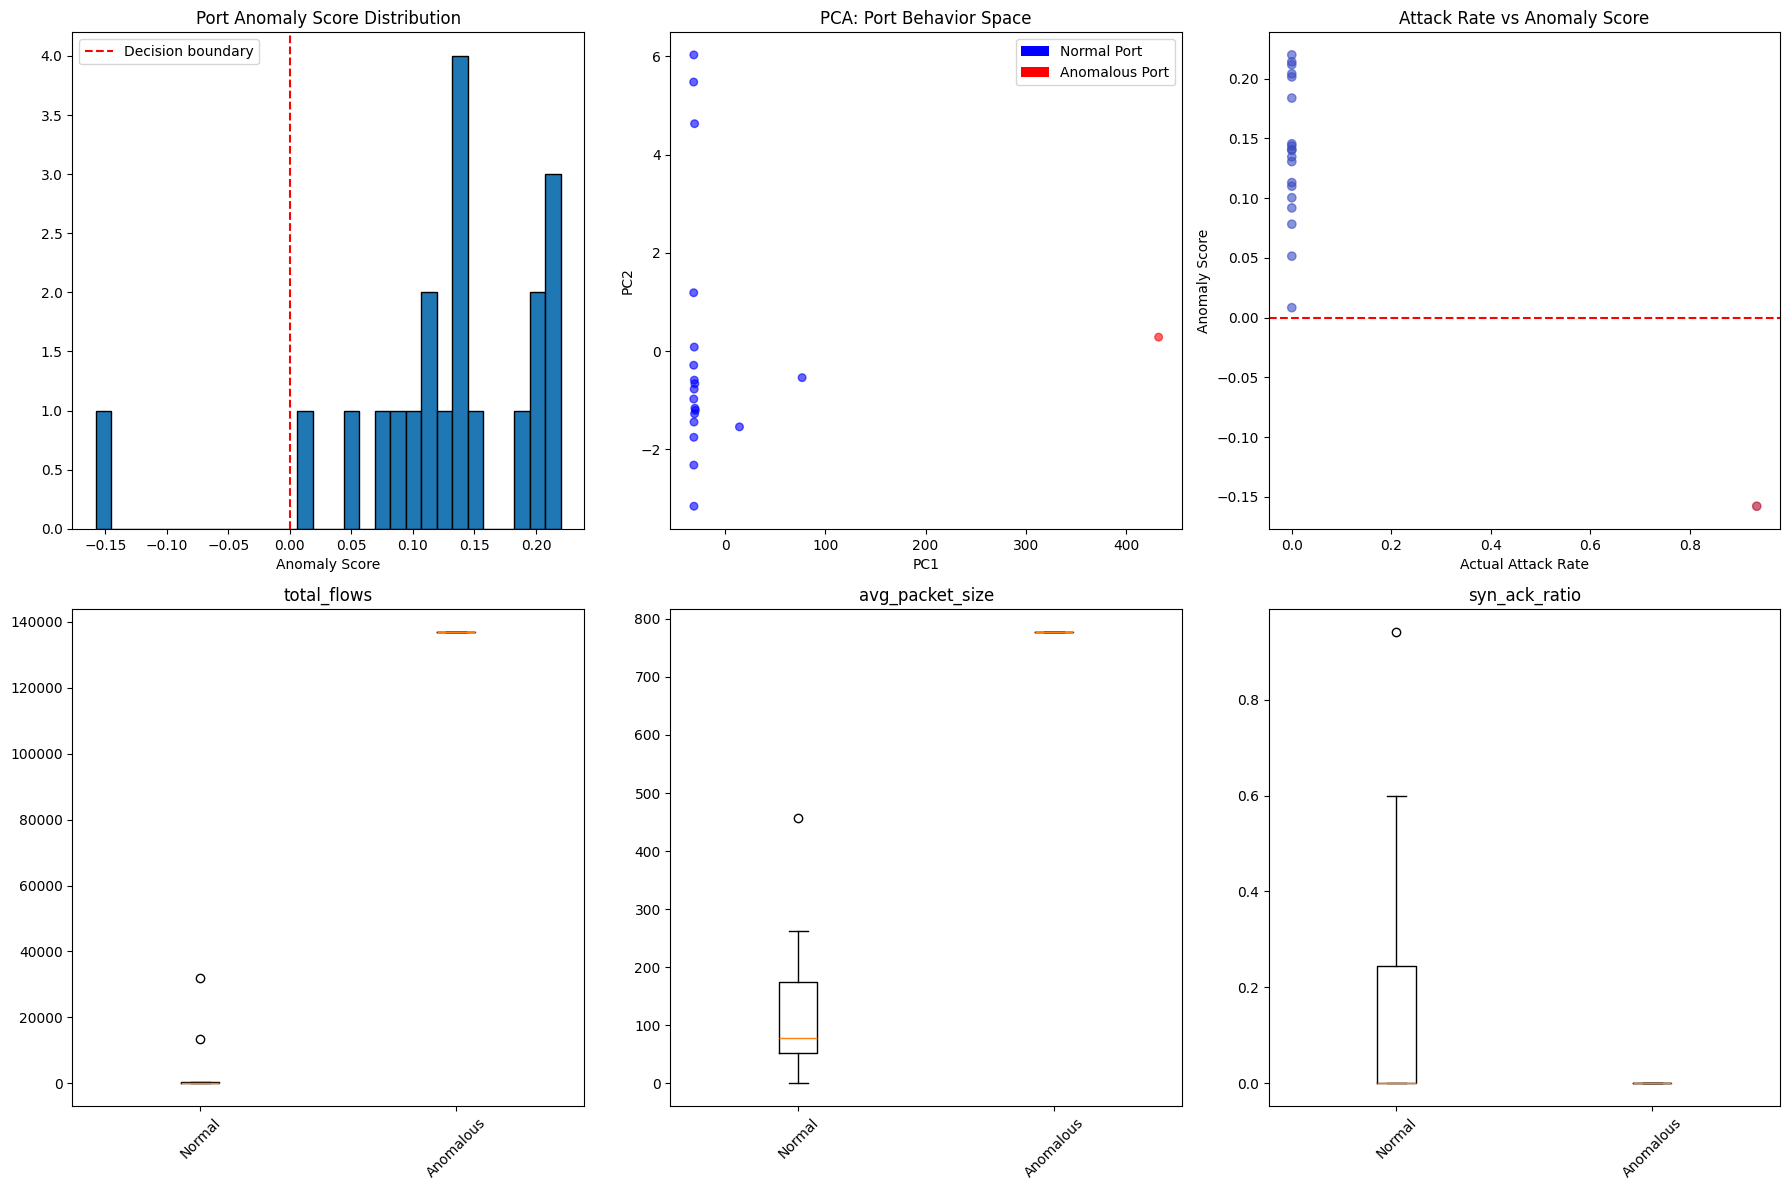

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Anomaly score distribution
axes[0,0].hist(port_df['anomaly_score'], bins=30, edgecolor='black')
axes[0,0].axvline(x=0, color='red', linestyle='--', label='Decision boundary')
axes[0,0].set_title('Port Anomaly Score Distribution')
axes[0,0].set_xlabel('Anomaly Score')
axes[0,0].legend()

# 2. PCA visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
colors = ['red' if p == 1 else 'blue' for p in port_df['predicted_anomaly']]
axes[0,1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.6, s=30)
axes[0,1].set_title('PCA: Port Behavior Space')
axes[0,1].set_xlabel('PC1')
axes[0,1].set_ylabel('PC2')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', label='Normal Port'),
                   Patch(facecolor='red', label='Anomalous Port')]
axes[0,1].legend(handles=legend_elements)

# 3. Attack rate vs anomaly score
axes[0,2].scatter(port_df['attack_rate'], port_df['anomaly_score'],
                  c=port_df['predicted_anomaly'], cmap='coolwarm', alpha=0.6)
axes[0,2].set_xlabel('Actual Attack Rate')
axes[0,2].set_ylabel('Anomaly Score')
axes[0,2].set_title('Attack Rate vs Anomaly Score')
axes[0,2].axhline(y=0, color='red', linestyle='--')

# 4-6. Compare features
top_features = ['total_flows', 'avg_packet_size', 'syn_ack_ratio']
for i, feature in enumerate(top_features):
    ax = axes[1, i]
    normal_vals = port_df[port_df['predicted_anomaly'] == 0][feature].dropna()
    anomaly_vals = port_df[port_df['predicted_anomaly'] == 1][feature].dropna()

    if len(normal_vals) > 0 and len(anomaly_vals) > 0:
        ax.boxplot([normal_vals, anomaly_vals], labels=['Normal', 'Anomalous'])
        ax.set_title(f'{feature}')
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('port_anomalies.png', dpi=150)
plt.show()

In [9]:
y_true = port_df['is_malicious_port']
y_pred = port_df['predicted_anomaly']

from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(f"               Predicted Normal  Predicted Anomaly")
print(f"Actual Normal      {tn:6d}           {fp:6d}")
print(f"Actual Malicious   {fn:6d}           {tp:6d}")

#classification report
print(classification_report(y_true, y_pred, target_names=['Normal Port', 'Malicious Port']))

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nPrecision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1-Score: {f1:.2%}")


Confusion Matrix:
               Predicted Normal  Predicted Anomaly
Actual Normal          19                0
Actual Malicious        0                1
                precision    recall  f1-score   support

   Normal Port       1.00      1.00      1.00        19
Malicious Port       1.00      1.00      1.00         1

      accuracy                           1.00        20
     macro avg       1.00      1.00      1.00        20
  weighted avg       1.00      1.00      1.00        20


Precision: 100.00%
Recall: 100.00%
F1-Score: 100.00%


In [10]:
# Get all anomalous ports
anomalous_ports = port_df[port_df['predicted_anomaly'] == 1].sort_values('anomaly_score')

print(f"\nFound {len(anomalous_ports)} anomalous ports:")
print(anomalous_ports[['port', 'total_flows', 'attack_rate', 'anomaly_score']].to_string())

# Detailed investigation of each anomalous port
for idx, row in anomalous_ports.iterrows():
    print(f"\n{'▬'*60}")
    print(f"🔍 INVESTIGATION REPORT: Port {int(row['port'])}")
    print(f"{'▬'*60}")

    # Port service mapping
    common_ports = {
        80: 'HTTP', 443: 'HTTPS', 22: 'SSH', 21: 'FTP', 25: 'SMTP',
        53: 'DNS', 3389: 'RDP', 445: 'SMB', 1433: 'MSSQL', 3306: 'MySQL',
        8080: 'HTTP-Alt', 8443: 'HTTPS-Alt', 20: 'FTP-Data', 23: 'Telnet',
        161: 'SNMP', 389: 'LDAP', 636: 'LDAPS', 993: 'IMAPS', 995: 'POP3S'
    }

    port_num = int(row['port'])
    service = common_ports.get(port_num, 'Unknown/Registered')

    print(f"\n📋 PORT DETAILS:")
    print(f"  • Port Number: {port_num}")
    print(f"  • Service: {service}")
    print(f"  • Total Flows: {row['total_flows']:,}")
    print(f"  • Attack Rate: {row['attack_rate']:.2%}")
    print(f"  • Anomaly Score: {row['anomaly_score']:.4f}")

    print(f"\n📊 BEHAVIORAL DEVIATIONS:")

    # Compare each feature to population
    for feature in ['total_flows', 'avg_flow_duration', 'avg_packet_size',
                    'avg_packet_rate', 'syn_ack_ratio']:
        if feature in row:
            port_val = row[feature]
            pop_mean = port_df[feature].mean()
            pop_std = port_df[feature].std()
            pop_median = port_df[feature].median()

            if pop_std > 0:
                z_score = (port_val - pop_mean) / pop_std
                percentile = (port_df[feature] < port_val).mean() * 100

                if abs(z_score) > 2:
                    direction = "higher" if z_score > 0 else "lower"
                    print(f"  • {feature}: {port_val:.2f}")
                    print(f"    - Population avg: {pop_mean:.2f}, median: {pop_median:.2f}")
                    print(f"    - Deviation: {direction} by {abs(z_score):.1f}σ")
                    print(f"    - Percentile: {percentile:.1f}th")

    #THREAT ASSESSMENT

    if row['attack_rate'] > 0.9:
        print(f"  ⚠️ CRITICAL: Port {port_num} is {row['attack_rate']:.0%} attack traffic")
        if port_num in [80, 443, 8080]:
            print("    - Web service under DDoS attack")
        elif port_num in [22, 3389]:
            print("    - Remote access service under brute force attack")
        elif port_num in [53]:
            print("    - DNS amplification attack possible")
        elif port_num in [1433, 3306]:
            print("    - Database service under attack")
        else:
            print("    - Service is being targeted by attackers")

    if 'syn_ack_ratio' in row and row['syn_ack_ratio'] > 5:
        print(f"  ⚠️ High SYN/ACK ratio ({row['syn_ack_ratio']:.2f})")
        print("    - Indicates SYN flood attack or port scanning")

    if 'avg_packet_size' in row and row['avg_packet_size'] < 100:
        print(f"  ⚠️ Very small average packet size ({row['avg_packet_size']:.0f} bytes)")
        print("    - Characteristic of attack traffic or C2 beaconing")

    if 'total_flows' in row and row['total_flows'] > port_df['total_flows'].quantile(0.95):
        print(f"  ⚠️ Unusually high volume ({row['total_flows']:,} flows)")
        print("    - Possible DDoS flood or mass scanning")


Found 1 anomalous ports:
   port  total_flows  attack_rate  anomaly_score
4    80       136951     0.934816      -0.157938

▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬
🔍 INVESTIGATION REPORT: Port 80
▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬

📋 PORT DETAILS:
  • Port Number: 80
  • Service: HTTP
  • Total Flows: 136,951.0
  • Attack Rate: 93.48%
  • Anomaly Score: -0.1579

📊 BEHAVIORAL DEVIATIONS:
  • total_flows: 136951.00
    - Population avg: 9252.10, median: 157.00
    - Deviation: higher by 4.1σ
    - Percentile: 95.0th
  • avg_packet_size: 777.49
    - Population avg: 151.89, median: 81.55
    - Deviation: higher by 3.4σ
    - Percentile: 95.0th
  ⚠️ CRITICAL: Port 80 is 93% attack traffic
    - Web service under DDoS attack
  ⚠️ Unusually high volume (136,951.0 flows)
    - Possible DDoS flood or mass scanning
